In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import rasterio
from matplotlib import pyplot as plt
from rasterio.windows import Window
import scipy
import glob
import os
import shutil
import datetime as dt
from osgeo import gdal
from dask.distributed import Client
import rioxarray
from xarray import apply_ufunc
from geetools import ERA5
from closig.expansion import SmallStepBasis, TwoHopBasis
from scipy.optimize import least_squares

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [3]:
from itrip.slc_stack import StackTIF

window = Window(17000, 2500, 10000, 4000)
startDate = dt.datetime(2016, 1, 1)
endDate = dt.datetime(2022, 1, 1)
cslc_stack = StackTIF("/data/rb894/SAR/S1/vegas/SLC/merged", 
    window=window,
    startDate=startDate, 
    endDate=endDate)
print(cslc_stack.P)

/home/rb894/miniforge3/envs/insar/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


getting dates
setting up stack
84


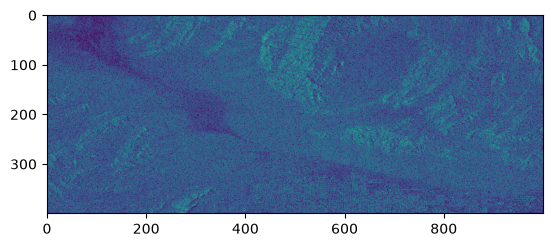

In [4]:
plt.imshow(np.log10(np.abs(cslc_stack.read(2)))[::10, ::10], vmin=1, vmax=4)
plt.show()

Retrieving timeseries (this may take a few seconds)...


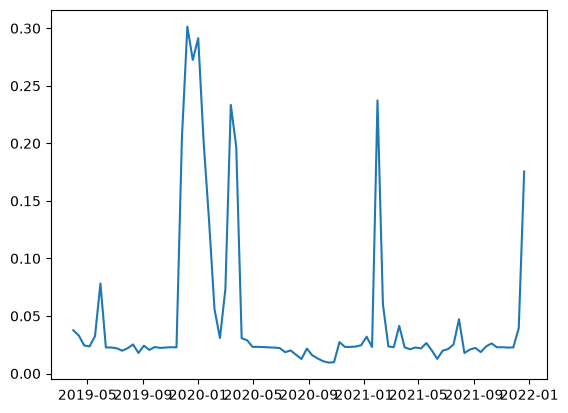

In [5]:
lonlat = (-115.30637191528919, 36.37376240739673)
date_pattern = '%Y-%m-%d'

start_date = cslc_stack.datetimes[0] + dt.timedelta(days=-1)
end_date = cslc_stack.datetimes[-1] + dt.timedelta(days=1)
gee_sd = start_date.strftime(date_pattern)
gee_ed = end_date.strftime(date_pattern)

era5_df = ERA5.get_era5_ts(lonlat[1], lonlat[0], gee_sd, gee_ed)
filtered_df = era5_df[era5_df["time"].isin(cslc_stack.datetimes)]
plt.plot(filtered_df['time'], filtered_df['volumetric_soil_water_layer_1'])
plt.show()

In [6]:
lf = 15
ml_size = (1*lf, 7*lf)
sample_size = (20, 40)
infgm_folder = os.path.join(cslc_stack.path, f'./wrapped_{ml_size[0]}_{ml_size[1]}')
print(infgm_folder)

/data/rb894/SAR/S1/vegas/SLC/merged/./wrapped_15_105


In [7]:
pairs = cslc_stack.get_pairs(diag=True, connectN=20, maxDays=1000)
pairsa = np.array(pairs)

In [8]:
if False:
    if os.path.exists(infgm_folder):
        print('Folder exists already. Overwriting...')
        shutil.rmtree(infgm_folder)
    os.mkdir(infgm_folder)

    with Client(
        dashboard_address=":8787",  # optional fixed dashboard port
        memory_limit="15GB",
        n_workers=5,
        threads_per_worker=1,

    ) as client:
        print('DASHBOARD: ', client.dashboard_link)
        futures = client.map(
            cslc_stack.interferogram,
            pairs,
            out_folder=infgm_folder,
            ml_size=ml_size,
            sample_size=sample_size,
        )
        client.gather(futures)

In [9]:
infgm_files = sorted(glob.glob(os.path.join(infgm_folder, './*.infgm.ml.tif')))
infgm_vrt = os.path.join(infgm_folder, './infgm_stack.vrt')
vrt = gdal.BuildVRT(infgm_vrt, infgm_files, separate=True)
vrt = None

In [10]:
da = rioxarray.open_rasterio(
    infgm_vrt,
    chunks={
        "band": -1,
        "x": 16,
        "y": 16,
    },
)

In [11]:
P = cslc_stack.P
triui = np.triu_indices(P)
triui1 = np.triu_indices(P, k=1)
# diag = triui[0] == triui[1]
diag = pairsa.T[0] == pairsa.T[1]

def triu_index(i, j, P): ## Inverse triui
    return i*P - i*(i-1)//2 + (j - i)

In [ ]:
from itrip.arctan import closureResiduals, jacobian

In [34]:
basis_type = 'TwoHop'
max_ptau = 2


if basis_type == 'TwoHop':
    basis = TwoHopBasis(P)
elif basis_type == 'SmallStep':
    basis = SmallStepBasis(P)

cphases = None
covectors = np.array(basis.covectors, dtype='object')
closure_mask = basis.ptau <= max_ptau
covectors = covectors[closure_mask]
basis.covectors = covectors

In [36]:
from tqdm import tqdm
errors = []
basis_type = 'TwoHop'

for max_ptau in tqdm([2, 4, 6, 8, 10, 12, 14, 16, 18]):
    if basis_type == 'TwoHop':
        basis = TwoHopBasis(P)
    elif basis_type == 'SmallStep':
        basis = SmallStepBasis(P)

    cphases = None
    covectors = np.array(basis.covectors, dtype='object')
    closure_mask = basis.ptau <= max_ptau
    covectors = covectors[closure_mask]
    basis.covectors = covectors

    def closurePhases(data, **kwargs):
        cov = np.zeros((data.shape[0], data.shape[1], P, P), dtype=np.complex64)
        n_full = data.shape[0] - P
        cov[:, :, pairsa.T[0], pairsa.T[1]] = data
        cov[~np.isfinite(cov)] = 0
        intensity = 10 * np.log10(np.abs(data[:, :, diag]))
        cov /= np.abs(cov)
        closure_stack = basis.evaluate_covariance(cov, compl=True, normalize=False).astype(np.complex64)
        b = np.zeros((data.shape[0], data.shape[1]), dtype=np.float32)

        for i in range(closure_stack.shape[1]):
            for j in range(closure_stack.shape[2]):
                try: 
                    validCovectors = covectors[np.isfinite(closure_stack[:, i, j])]
                    x0 = np.random.normal(0.1, 0.5)
                    validMask = np.isfinite(closure_stack[:, i, j])
                    validCovectors = covectors[validMask]

                    intensity[i, j][~np.isfinite(intensity[i, j])] = np.nanmean(intensity[i, j])

                    inversion = least_squares(closureResiduals, 
                        x0=[x0], 
                        args=(closure_stack[:, i, j][validMask], intensity[i, j], validCovectors),
                        jac=jacobian,
                        ftol=1e-2,
                        xtol=1e-2,
                        method="lm", 
                        loss='linear')
                    b[i, j] = inversion['x'][0]
                except Exception as e:
                    print(e)
                    # print(closure_stack[:, i, j])
                    errors.append(f'{i},{j}: {e}')
                    continue
        return b
    result_closurePhases = apply_ufunc(
        closurePhases,
        da,
        input_core_dims=[["band"]],
        output_core_dims=[[]],
        output_dtypes=[np.float32],
        dask="parallelized",
        keep_attrs=True,
    )

    with Client(
        dashboard_address=":8787",  # optional fixed dashboard port
    ) as client:
        print('DASHBOARD: ', client.dashboard_link)
        future = client.compute(result_closurePhases)
        result = future.result()
    result.rio.to_raster(f"/data/rb894/SAR/S1/vegas/itriplet/arctanFit_{basis_type}_{max_ptau}.tif")

  0%|          | 0/9 [00:00<?, ?it/s]/home/rb894/miniforge3/envs/insar/lib/python3.12/site-packages/dask/array/utils.py:105: ComplexWarning: Casting complex values to real discards the imaginary part
  meta = meta.astype(dtype)


DASHBOARD:  http://127.0.0.1:8787/status


/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountere

DASHBOARD:  http://127.0.0.1:8787/status


/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountere

...

/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountere

DASHBOARD:  http://127.0.0.1:8787/status


/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountere

DASHBOARD:  http://127.0.0.1:8787/status


/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_394298/2487244592.py:23: RuntimeWarning: invalid value encountere

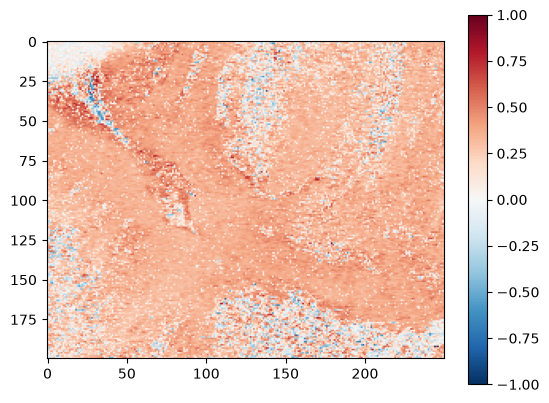

In [37]:
plt.imshow(result, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar()
plt.show()

/home/rb894/miniforge3/envs/insar/lib/python3.12/site-packages/rioxarray/raster_writer.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  float(original_nodata)


In [17]:
# Select one 16x16 chunk
chunk = da.isel(
    y=slice(100, 130),
    x=slice(100, 130),
)

# Actually read it into memory
chunk = chunk.load()

(30, 30, 3654)
Running inversions


/tmp/ipykernel_56791/1678245013.py:8: RuntimeWarning: invalid value encountered in divide
  cov /= np.abs(cov)
/tmp/ipykernel_56791/1678245013.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.plot(10 * np.log10(np.abs(cov_diag)[3, 5, :]))


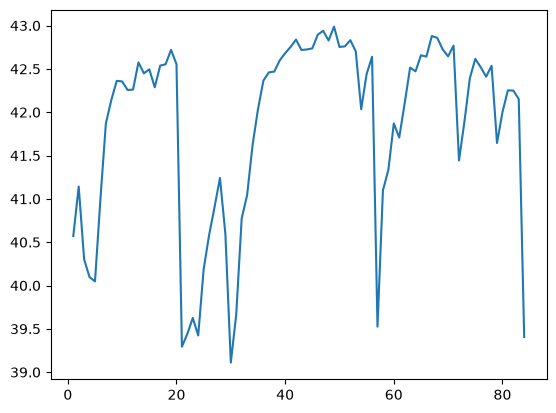

In [51]:
data = chunk.transpose('x', 'y', 'band').values
cov = np.zeros((data.shape[0], data.shape[1], P, P), dtype=np.complex64)
n_full = data.shape[0] - P
cov[:, :, pairsa.T[0], pairsa.T[1]] = data
print(data.shape)   
cov_diag = data[:, :, diag]
# cov += cov.transpose(0, 1, 3, 2).conj()
cov /= np.abs(cov)
closure_stack = basis.evaluate_covariance(cov, compl=True, normalize=False).astype(np.complex64)
b = np.zeros((data.shape[0], data.shape[1]), dtype=np.float32)
print('Running inversions')

plt.plot(10 * np.log10(np.abs(cov_diag)[3, 5, :]))
plt.show()

# print(np.abs(cov_diag)[6, 6, :])

/tmp/ipykernel_56791/3970708361.py:3: RuntimeWarning: divide by zero encountered in log10
  intensity = 20 * np.log10(np.abs(cov_diag[i, j]))
/tmp/ipykernel_56791/3970708361.py:5: RuntimeWarning: invalid value encountered in subtract
  dI = intensity[:, None] - intensity[None, :]


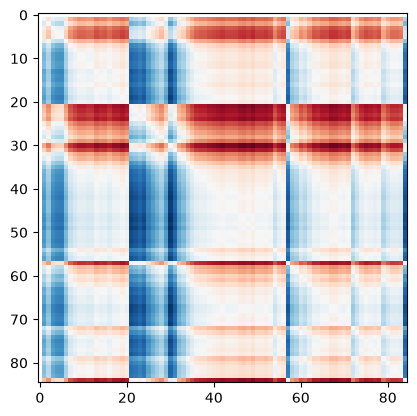

In [52]:
i, j = (3, 5)

intensity = 20 * np.log10(np.abs(cov_diag[i, j]))
intensity[~np.isfinite(intensity)] = np.nanmean(intensity)
dI = intensity[:, None] - intensity[None, :]
plt.imshow(dI, cmap='RdBu')
plt.show()

In [53]:
def intensity_closure(intensity, covector, b):
    output = 0
    for i in range(len(covector)):
        cv = covector[i]
        idif = (intensity[cv[1]] - intensity[cv[0]])
        output += cv[-1] * np.arctan(b * idif)    
    return output

def arctan_jac(intensity, covector, b):
    output = 0
    for i in range(len(covector)):
        cv = covector[i]
        idif = (intensity[cv[1]] - intensity[cv[0]])
        output += cv[-1] * idif / (idif**2 * b**2 + 1)
    return output

def forwardClosurePhases(intensity, b, covectors):
    predicted = np.zeros(len(covectors), dtype=np.float32)
    for i in range(len(covectors)):
        predicted[i] = intensity_closure(intensity, covectors[i], b=b)
    return np.exp(1j * predicted)

def jacobian(x, _, intensity, covectors):
    J = np.ones((len(covectors)), dtype=np.float64)
    for i in range(len(covectors)):
        J[i] = arctan_jac(intensity, covectors[i], b=x[0])
    return J[:, np.newaxis]

def closureResiduals(x, observedClosurePhases, intensity, validCovectors):
    predicted = forwardClosurePhases(intensity, x[0], validCovectors)
    residual = np.angle(predicted * observedClosurePhases.conj())
    return residual


x0 = np.random.normal(0.9, 0.5)

validMask = np.isfinite(closure_stack[:, i, j])
validCovectors = covectors[validMask]
print(validCovectors.shape)
print(closure_stack[:, i, j][validMask].shape)
print(np.log10(np.abs(cov_diag[i, j])).shape)
intensity = 20 * np.log10(np.abs(cov_diag[i, j]))
intensity[~np.isfinite(intensity)] = np.nanmean(intensity)

inversion = least_squares(closureResiduals, 
    x0=[0.3], 
    args=(closure_stack[:, i, j][validMask], intensity, validCovectors), 
    # bounds=bounds, 
    jac=jacobian,
    ftol=1e-2,
    xtol=1e-2,
    method="dogbox",
    loss='huber', 
    )   
print(f'index {i} {j}, result: ', inversion['x'])

# print(inversion)

(322,)
(322,)
(85,)
index 3 5, result:  [0.2011663]


/tmp/ipykernel_56791/146915082.py:41: RuntimeWarning: divide by zero encountered in log10
  print(np.log10(np.abs(cov_diag[i, j])).shape)
/tmp/ipykernel_56791/146915082.py:42: RuntimeWarning: divide by zero encountered in log10
  intensity = 20 * np.log10(np.abs(cov_diag[i, j]))


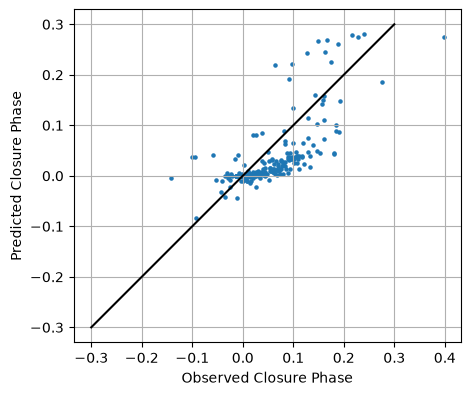

In [54]:
forwardClosure = forwardClosurePhases(intensity, inversion['x'][0], validCovectors)
# forwardClosure = forwardClosurePhases(intensity, 0.3, validCovectors)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
ax.scatter(np.angle(closure_stack[:, i, j][validMask]), np.angle(forwardClosure), s=5)
ax.plot([-0.3, 0.3], [-0.3, 0.3], color='black')
plt.xlabel('Observed Closure Phase')
plt.ylabel('Predicted Closure Phase')
plt.grid()
plt.show()

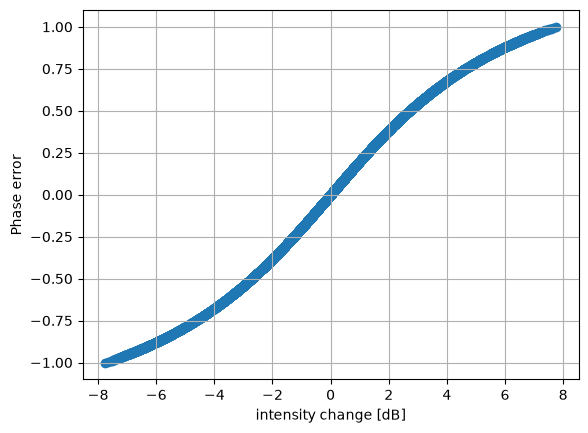

In [55]:
phases_forward = np.arctan((dI * inversion['x'][0]))
plt.scatter(dI.flatten(), phases_forward.flatten())
plt.ylabel('Phase error')
plt.xlabel('intensity change [dB]')
plt.grid()
plt.show()

In [56]:
def intensity_closure(intensity, covector, b, a):
    output = 0
    for i in range(len(covector)):
        cv = covector[i]
        idif = (intensity[cv[1]] - intensity[cv[0]])
        output += cv[-1] * np.arctan((b * idif) / (b**2 + a * (b**2 + idif**2)))    
    return output

def forwardClosurePhases(intensity, b, a, covectors):
    predicted = np.zeros(len(covectors), dtype=np.float32)
    for i in range(len(covectors)):
        predicted[i] = intensity_closure(intensity, covectors[i], b=b, a=a)
    return np.exp(1j * predicted)

def closureResiduals(x, observedClosurePhases, intensity, validCovectors):
    predicted = forwardClosurePhases(intensity, x[0], x[1], validCovectors)
    residual = np.angle(predicted * observedClosurePhases.conj())
    return residual

i, j = (3, 5)

x0 = np.random.normal(0.9, 0.5)

validMask = np.isfinite(closure_stack[:, i, j])
validCovectors = covectors[validMask]
print(validCovectors.shape)
print(closure_stack[:, i, j][validMask].shape)
print(np.log10(np.abs(cov_diag[i, j])).shape)
intensity = 20 * np.log10(np.abs(cov_diag[i, j]))
intensity[~np.isfinite(intensity)] = np.nanmean(intensity)

inversion = least_squares(closureResiduals, 
    x0=[3, 5], 
    args=(closure_stack[:, i, j][validMask], intensity, validCovectors), 
    # bounds=bounds, 
    ftol=1e-1,
    xtol=1e-1,
    method="dogbox", 
    loss='huber'
    )   
print(f'index {i} {j}, result: ', inversion['x'])

(322,)
(322,)
(85,)
index 3 5, result:  [1.6556356  5.76694891]


/tmp/ipykernel_56791/2176111952.py:28: RuntimeWarning: divide by zero encountered in log10
  print(np.log10(np.abs(cov_diag[i, j])).shape)
/tmp/ipykernel_56791/2176111952.py:29: RuntimeWarning: divide by zero encountered in log10
  intensity = 20 * np.log10(np.abs(cov_diag[i, j]))


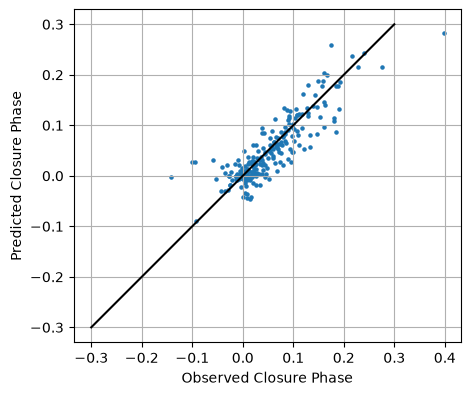

In [57]:
forwardClosure = forwardClosurePhases(intensity, inversion['x'][0], inversion['x'][1], validCovectors)
# forwardClosure = forwardClosurePhases(intensity, 5, 0, validCovectors)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
ax.scatter(np.angle(closure_stack[:, i, j][validMask]), np.angle(forwardClosure), s=5)
ax.plot([-0.3, 0.3], [-0.3, 0.3], color='black')
plt.xlabel('Observed Closure Phase')
plt.ylabel('Predicted Closure Phase')
plt.grid()
plt.show()

/tmp/ipykernel_56791/1587838685.py:1: RuntimeWarning: invalid value encountered in divide
  phases_forward = np.arctan((dI * inversion['x'][0]) / (inversion['x'][0]**2 * inversion['x'][1] * (inversion['x'][0]**2 + dI**2) ))


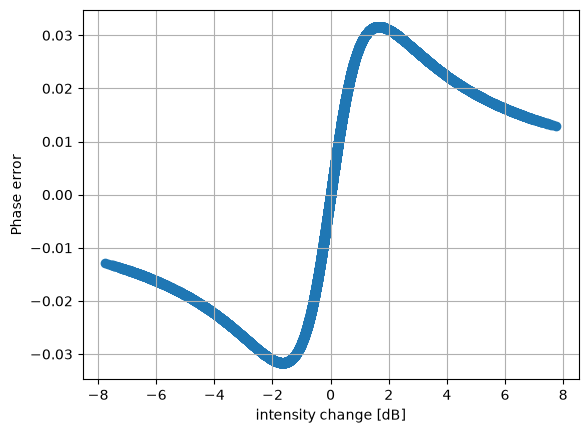

/tmp/ipykernel_56791/1587838685.py:8: RuntimeWarning: invalid value encountered in divide
  phases_forward = np.arctan((dI * 3) / (3**2 * 2 * (3**2 + dI**2) ))


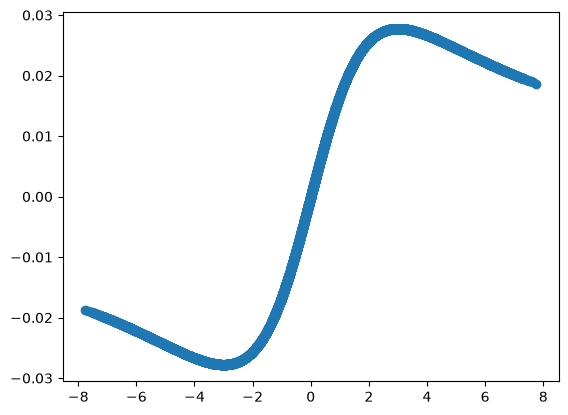

In [58]:
phases_forward = np.arctan((dI * inversion['x'][0]) / (inversion['x'][0]**2 * inversion['x'][1] * (inversion['x'][0]**2 + dI**2) ))
plt.scatter(dI.flatten(), phases_forward.flatten())
plt.ylabel('Phase error')
plt.xlabel('intensity change [dB]')
plt.grid()
plt.show()

phases_forward = np.arctan((dI * 3) / (3**2 * 2 * (3**2 + dI**2) ))
plt.scatter(dI.flatten(), phases_forward.flatten())
plt.show()